**Project Objective**

This project is focused on developing a fraud detection model. The dataset can be found on Kaggle.

**Missing values handling**

After analyzing the dataframe, it was verified that the variables do not contain missing values.

**Outlier treatment**

Outliers were identified using boxplots and histograms. However, when analyzing them individually, it was observed that most variables do not have more than 10% of outliers. Additionally, removing these outliers resulted in losing almost all cases from the target (minority) class, indicating that they are important for training. Therefore, we decided to keep them.

**Multicollinearity analysis**

The correlation matrix did not show very high or very low correlations, indicating that no multicollinearity treatment was necessary.

**Data split (train, validation, and test)**

The dataset was split into 70% for training, 15% for validation (hyperparameter tuning), and 15% for final testing.

**Balancing and standardization**

Several balancing techniques were tested, such as SMOTE, SMOTETomek, and ADASYN, but they introduced significant noise due to the large class imbalance. Therefore, the dataset was kept imbalanced.

Data standardization was performed using StandardScaler to ensure that all variables were on the same scale.

**Model selection**

A Logistic Regression model (baseline) and a Random Forest model were used. Random Forest performed significantly better on the imbalanced dataset, so it was selected for hyperparameter tuning to improve performance and reduce overfitting.

**Random Forest modeling**

Less important features were removed to reduce noise during training. The class_weight parameter was enabled to handle class imbalance, and n_jobs = -1 was used for parallel processing. Hyperparameters such as min_samples_leaf, min_samples_split, and n_estimators were tuned to control overfitting.

**Conclusion** 

The macro-average F1-score and the Precision-Recall curve were used, as they are more appropriate for imbalanced datasets. These metrics place greater emphasis on the performance of the minority class, which is the most important in this case. Metrics such as accuracy and the ROC curve can be misleading in imbalanced scenarios, as they may show good overall performance even when the model performs poorly on the minority class.

The model achieved 98% on the training set and 93% on the test set, indicating a 5% overfitting, reduced from the previous 7% before hyperparameter tuning.

In [253]:
#IMPORTS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_recall_curve
from sklearn.model_selection import GridSearchCV

In [5]:
#Dataset Upload
df = pd.read_csv("C:\\Users\\Clayton Miranda\\Desktop\\Modelos\\Datasets\\Fraude\\creditcard.csv")

In [ ]:
#Info of the Dataset 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

In [8]:
#Estatistics of the Dataset 
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

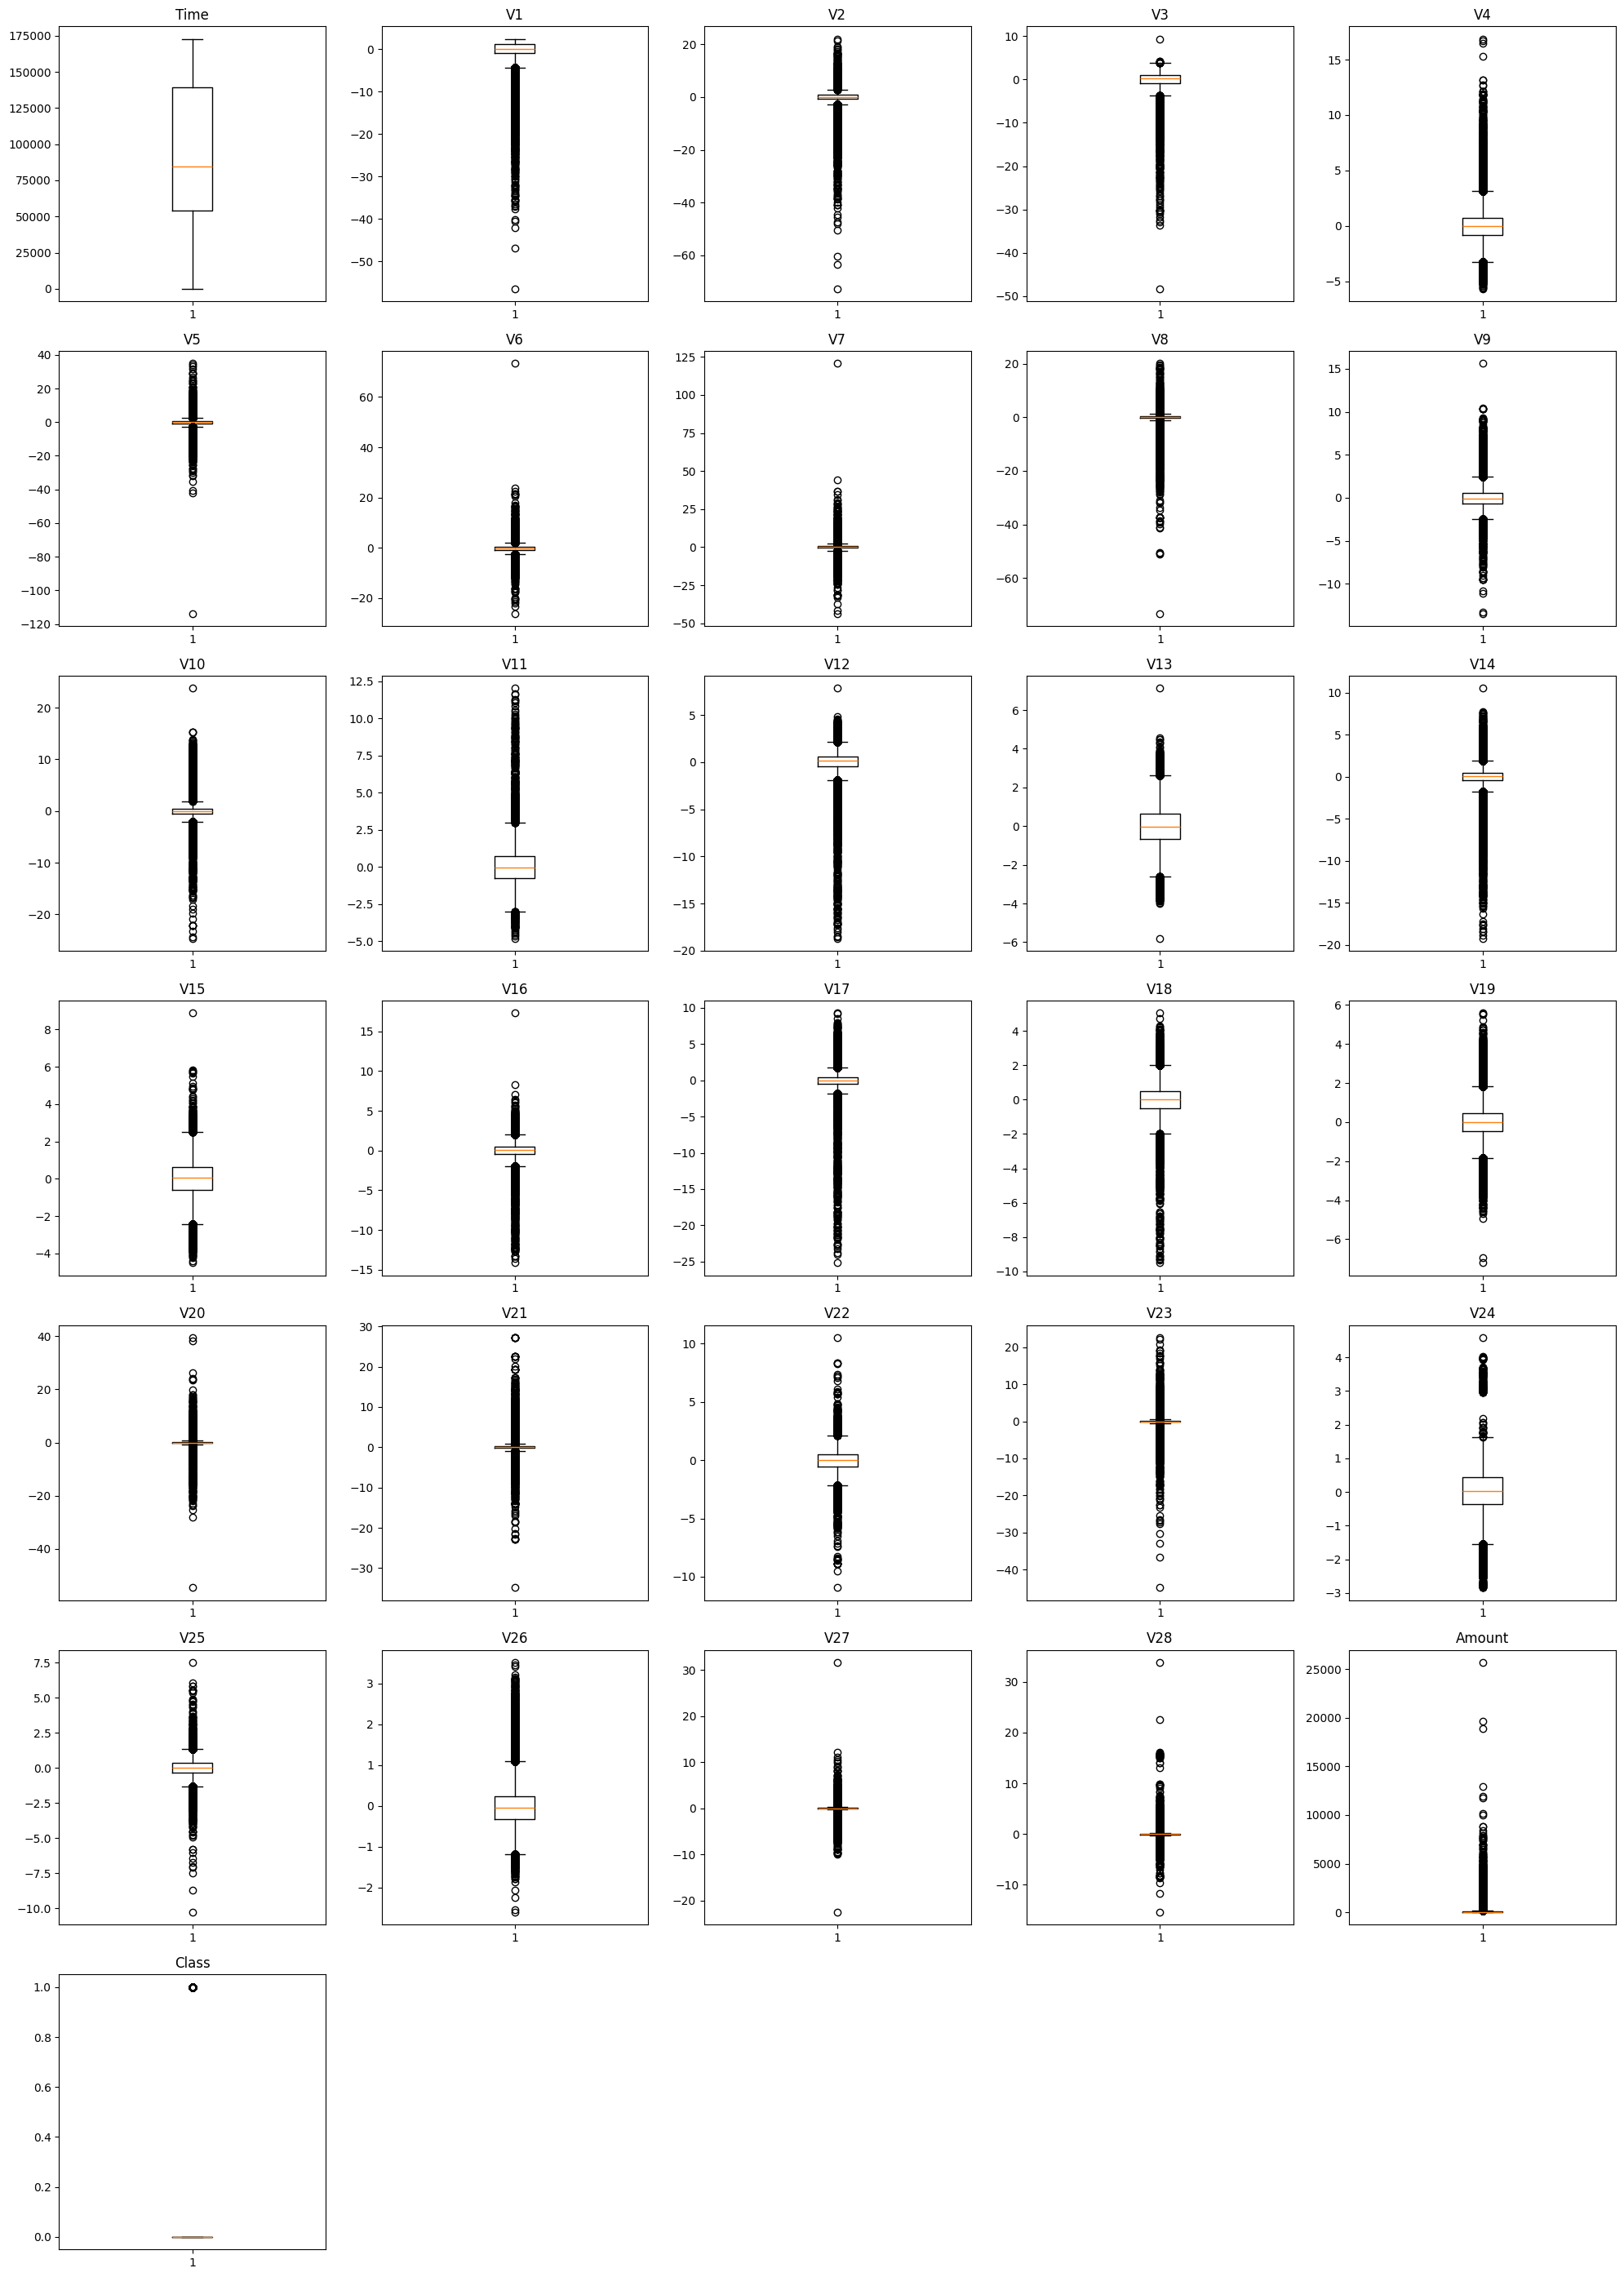

In [ ]:
#Boxplot
cols = df.columns
n_cols = 5
n_rows = math.ceil(len(cols)/n_cols)

plt.figure(figsize=(20, 20))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

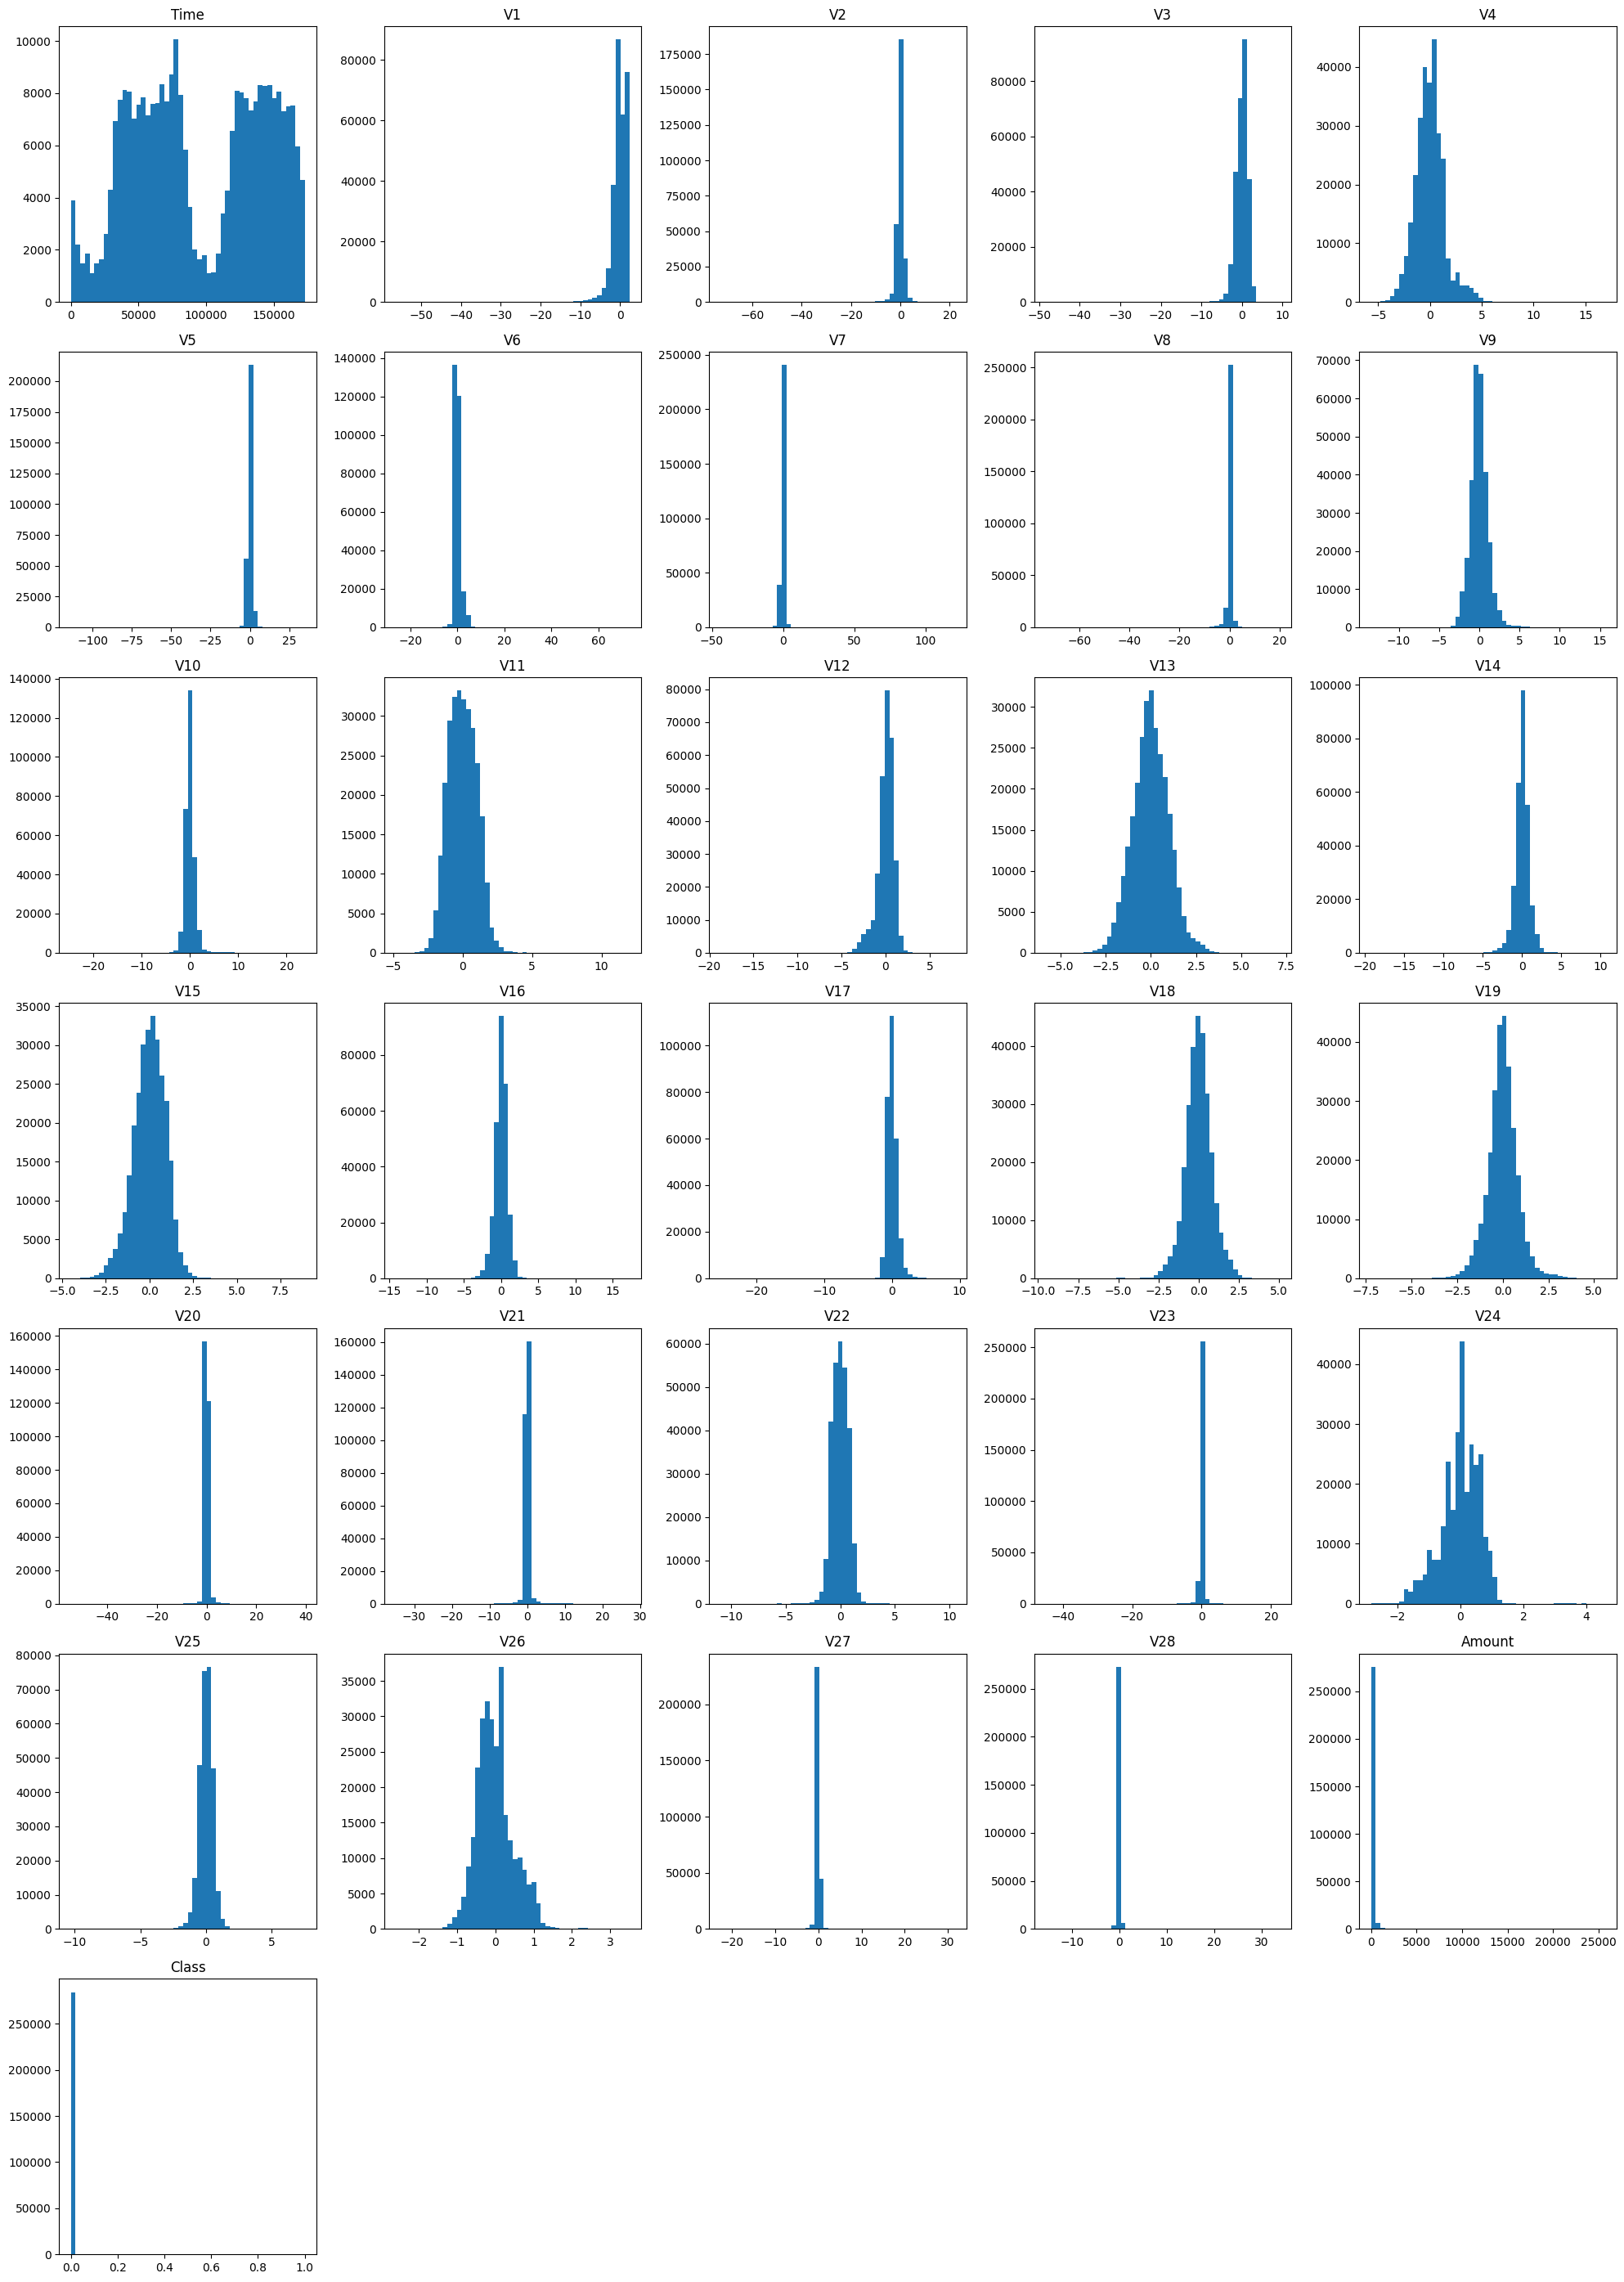

In [34]:
#Hist
cols = df.columns
n_cols = 5
n_rows = math.ceil(len(cols)/n_cols)

plt.figure(figsize=(20, 4*n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    plt.hist(df[col], bins=50)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
#Count outlier by varibles

for col in df.select_dtypes(include='number').columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    
    percentual = (len(outliers) / len(df)) * 100

    print(f"{col}: {percentual:.2f}%")

Time: 0.00%
V1: 2.48%
V2: 4.75%
V3: 1.18%
V4: 3.91%
V5: 4.32%
V6: 8.06%
V7: 3.14%
V8: 8.47%
V9: 2.91%
V10: 3.33%
V11: 0.27%
V12: 5.39%
V13: 1.18%
V14: 4.97%
V15: 1.02%
V16: 2.87%
V17: 2.61%
V18: 2.64%
V19: 3.58%
V20: 9.75%
V21: 5.09%
V22: 0.46%
V23: 6.51%
V24: 1.68%
V25: 1.88%
V26: 1.96%
V27: 13.75%
V28: 10.65%
Amount: 11.20%
Class: 0.17%


In [42]:
#Count number of fraud with and without outliers

X = df.drop(columns=["Class"])
y = df["Class"]


Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

mask = ~((X < (Q1 - 1.5*IQR)) | (X > (Q3 + 1.5*IQR))).any(axis=1)

X_clean = X[mask]
y_clean = y[mask]

df_clean = X_clean.copy()
df_clean["Class"] = y_clean

print(df['Class'].value_counts())
print(df_clean['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    146319
1        15
Name: count, dtype: int64


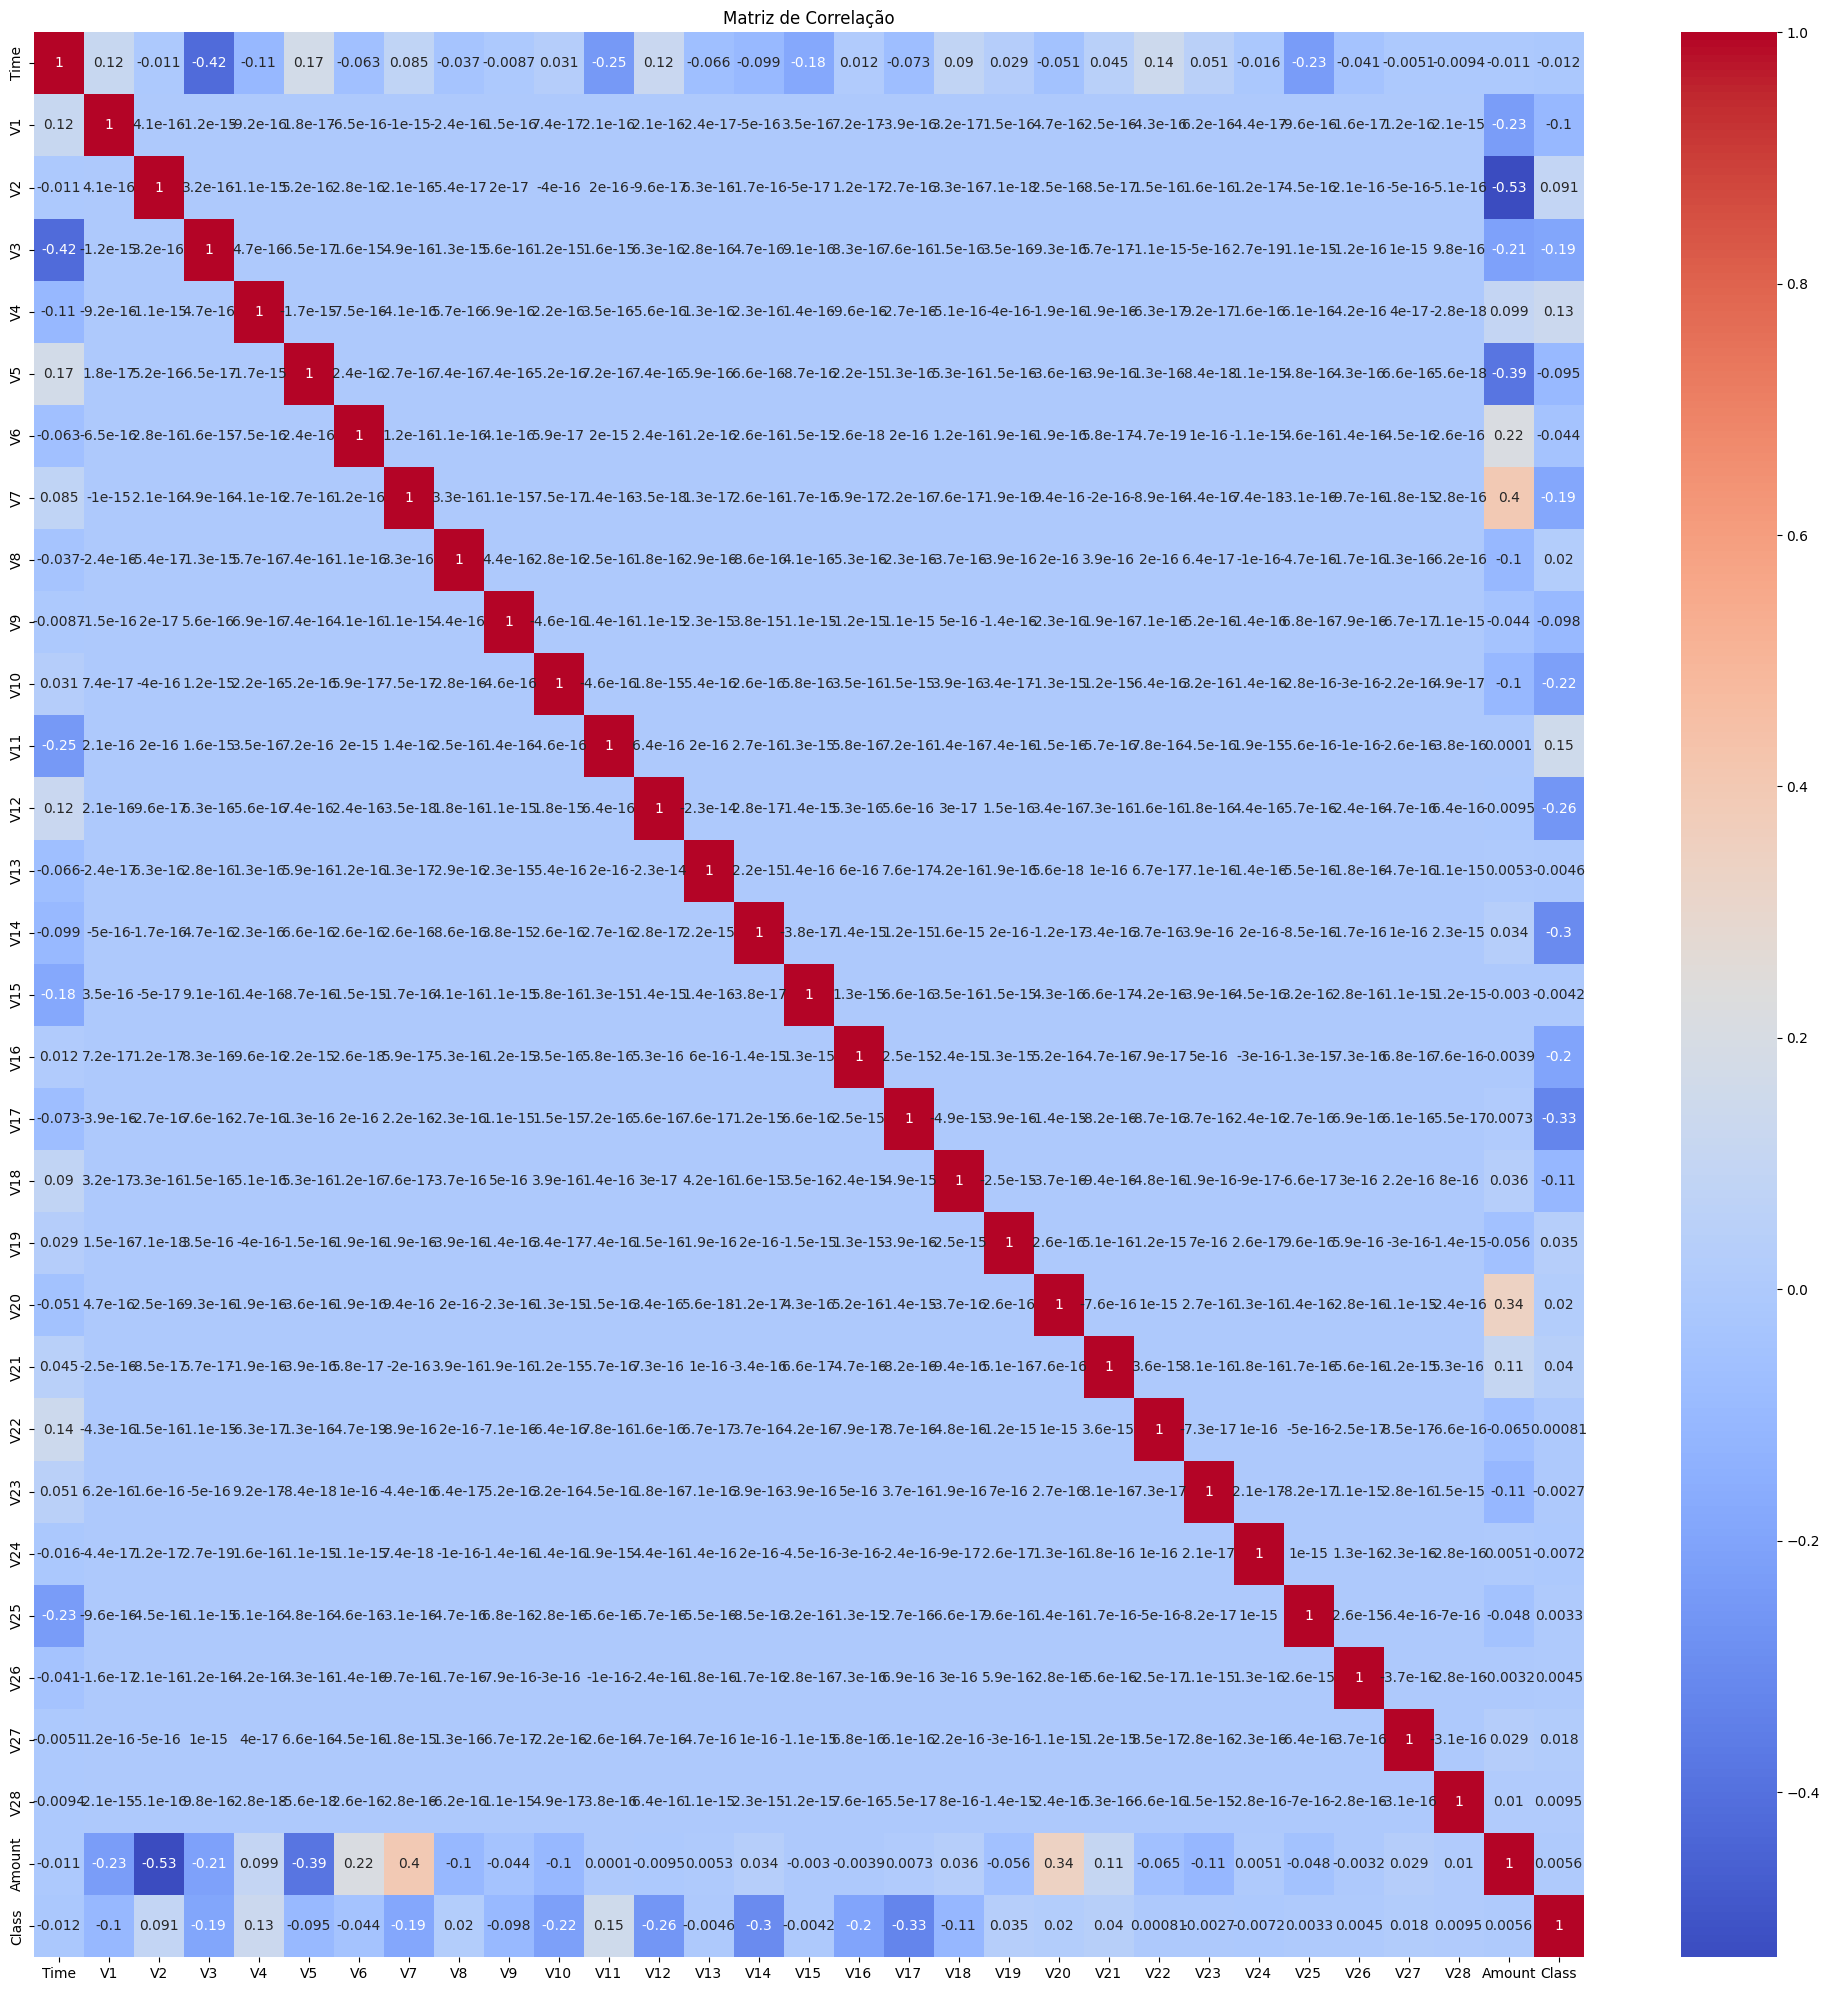

In [49]:
#Multicolinearidade

plt.figure(figsize=(25, 25))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

In [238]:
#Train, Test, Val
X_train_ub, X_temp, y_train_ub, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) 
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42) 

In [239]:
#Balanced
somete = SMOTE(random_state=42)
X_train, y_train = somete.fit_resample(X_train_ub, y_train_ub)

print(y_train_ub.value_counts())
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


In [240]:
#Standardization - Balanced Data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [241]:
#Standardization - Unbalanced

scaler_ub = StandardScaler()

X_train_scaled_ub = scaler_ub.fit_transform(X_train_ub)
X_test_scaled_ub = scaler_ub.transform(X_test)
X_val_scaled_ub = scaler_ub.transform(X_val)

In [279]:
#Logistic Regression - Balanced
model_lr = LogisticRegression()
lr1 = model_lr.fit(X_train_scaled, y_train)
y_lr1_pred = lr1.predict(X_train_scaled)
y_lr1_pred_val = lr1.predict(X_val_scaled)

print(classification_report(y_train, y_lr1_pred))
print(classification_report(y_val, y_lr1_pred_val))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    227451
           1       0.99      0.97      0.98    227451

    accuracy                           0.98    454902
   macro avg       0.98      0.98      0.98    454902
weighted avg       0.98      0.98      0.98    454902

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     28432
           1       0.13      0.86      0.23        49

    accuracy                           0.99     28481
   macro avg       0.56      0.92      0.61     28481
weighted avg       1.00      0.99      0.99     28481



In [280]:
#Logistic Regression - Unbalanced Data
lr2 = model_lr.fit(X_train_scaled_ub, y_train_ub)
y_lr2_pred = lr2.predict(X_train_scaled_ub)
y_lr2_pred_val = lr2.predict(X_val_scaled_ub)

print(classification_report(y_train_ub, y_lr2_pred))
print(classification_report(y_val, y_lr2_pred_val))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.88      0.63      0.73       394

    accuracy                           1.00    227845
   macro avg       0.94      0.81      0.87    227845
weighted avg       1.00      1.00      1.00    227845

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.79      0.61      0.69        49

    accuracy                           1.00     28481
   macro avg       0.89      0.81      0.84     28481
weighted avg       1.00      1.00      1.00     28481



In [281]:
#Random Forest - Balanced Data
model_rf = RandomForestClassifier()
rf1 = model_rf.fit(X_train_scaled, y_train)
y_rf1_pred = rf1.predict(X_train_scaled)
y_rf1_pred_val = rf1.predict(X_val_scaled)

print(classification_report(y_train, y_rf1_pred))
print(classification_report(y_val, y_rf1_pred_val))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00    227451

    accuracy                           1.00    454902
   macro avg       1.00      1.00      1.00    454902
weighted avg       1.00      1.00      1.00    454902

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.83      0.82      0.82        49

    accuracy                           1.00     28481
   macro avg       0.92      0.91      0.91     28481
weighted avg       1.00      1.00      1.00     28481



In [282]:
#Random Forest - Unbalanced
rf2 = model_rf.fit(X_train_scaled_ub, y_train_ub)
y_rf2_pred = rf2.predict(X_train_scaled_ub)
y_rf2_pred_val = rf2.predict(X_val_scaled_ub)

print(classification_report(y_train_ub, y_rf2_pred))
print(classification_report(y_val, y_rf2_pred_val))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.95      0.80      0.87        49

    accuracy                           1.00     28481
   macro avg       0.98      0.90      0.93     28481
weighted avg       1.00      1.00      1.00     28481



In [242]:
#Transforming the best data into a DataFrame

X_train_df = pd.DataFrame(X_train_scaled_ub)
X_test_df = pd.DataFrame(X_test_scaled_ub)
X_val_df = pd.DataFrame(X_val_scaled_ub)

In [243]:
#Eliminating the least important features for the model.

importances = pd.DataFrame({
    "feature": X_train_df.columns,
    "importance": model_rf.feature_importances_
})

selected_features = importances.loc[importances["importance"] > 0.01, "feature"]

X_train_sel = X_train_df[selected_features]
X_val_sel = X_val_df[selected_features]
X_test_sel = X_test_df[selected_features]

print("Features selecionadas:")
print(selected_features)

Features selecionadas:
0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
20    20
21    21
26    26
27    27
28    28
29    29
Name: feature, dtype: int64


C:\Users\Clayton Miranda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\Clayton Miranda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


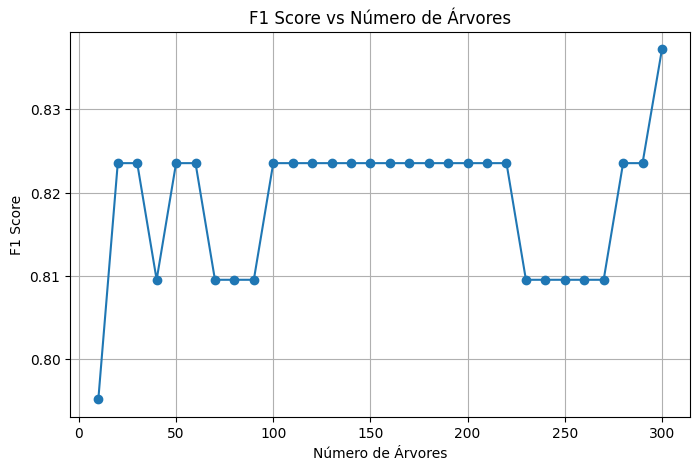

In [261]:
#Modeling the best model and data
trees = []
f1_scores = []

for n in range(10, 301, 10):

    model = RandomForestClassifier(
        n_estimators=n,
        class_weight="balanced",
        n_jobs=-1,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    
    model.fit(X_train_sel, y_train_ub)
    
    y_pred = model.predict(X_val_sel)
    
    f1 = f1_score(y_val, y_pred)
    
    trees.append(n)
    f1_scores.append(f1)

plt.figure(figsize=(8,5))
plt.plot(trees, f1_scores, marker='o')
plt.xlabel("Número de Árvores")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Número de Árvores")
plt.grid(True)
plt.show()

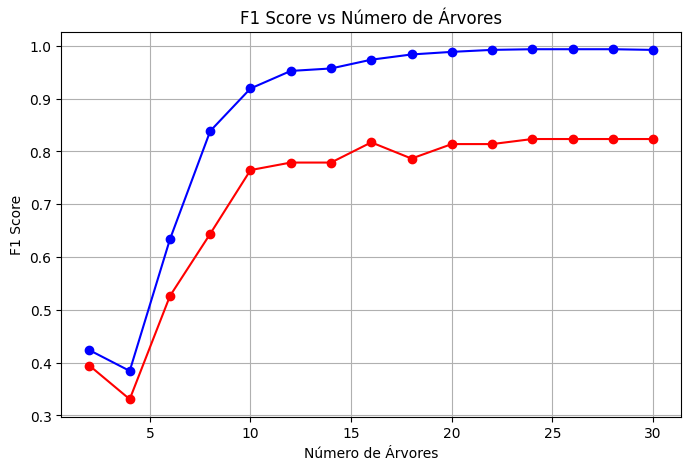

In [ ]:
#Modeling the best model and data
depth = []
f1_scores_train = []
f1_scores_val = []

for n in range(2, 31, 2):

    model = RandomForestClassifier(
        n_estimators=30,
        class_weight="balanced",
        n_jobs=-1,
        max_depth=n,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    
    model.fit(X_train_sel, y_train_ub)
    
    y_pred_train = model.predict(X_train_sel)    
    y_pred_val = model.predict(X_val_sel)
    
    
    f1_train = f1_score(y_train_ub, y_pred_train)
    f1_val = f1_score(y_val, y_pred_val)
    
    depth.append(n)
    f1_scores_train.append(f1_train)
    f1_scores_val.append(f1_val)

plt.figure(figsize=(8,5))
plt.plot(depth, f1_scores_train, marker='o', color='blue')
plt.plot(depth, f1_scores_val, marker='o', color='red')
plt.xlabel("Depth")
plt.ylabel("F1 Score")
plt.title("Max Depth")
plt.grid(True)
plt.show()

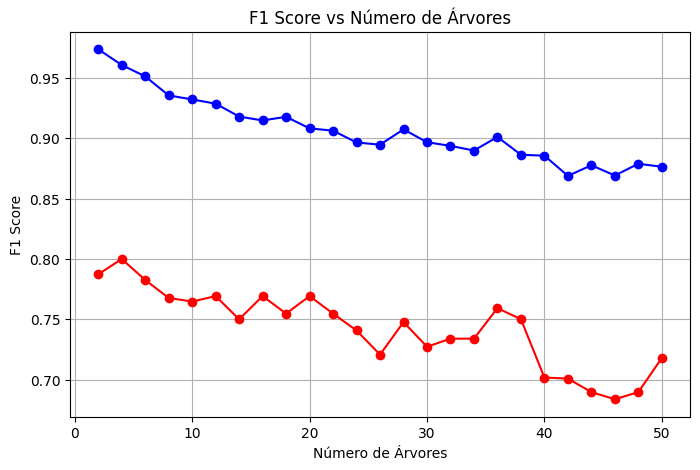

In [272]:
#Modeling the best model and data
leaf = []
f1_scores_train = []
f1_scores_val = []

for n in range(2, 51, 2):

    model = RandomForestClassifier(
        n_estimators=30,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=n,
        max_depth=16,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    
    model.fit(X_train_sel, y_train_ub)
    
    y_pred_train = model.predict(X_train_sel)    
    y_pred_val = model.predict(X_val_sel)
    
    
    f1_train = f1_score(y_train_ub, y_pred_train)
    f1_val = f1_score(y_val, y_pred_val)
    
    leaf.append(n)
    f1_scores_train.append(f1_train)
    f1_scores_val.append(f1_val)

plt.figure(figsize=(8,5))
plt.plot(leaf, f1_scores_train, marker='o', color='blue')
plt.plot(leaf, f1_scores_val, marker='o', color='red')
plt.xlabel("Leaf")
plt.ylabel("F1 Score")
plt.title("Min Samples Leaf")
plt.grid(True)
plt.show()

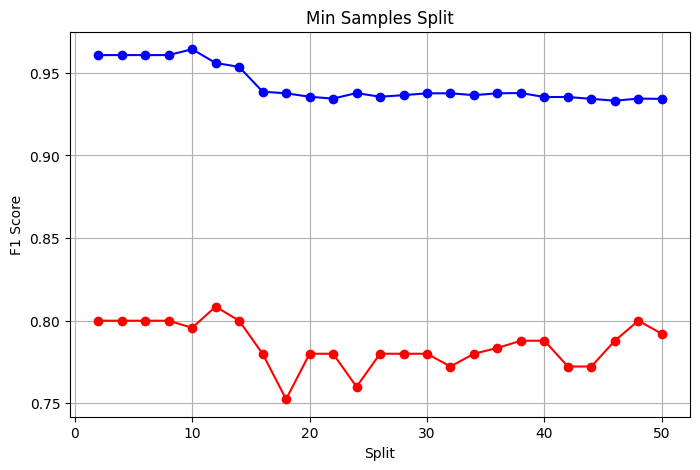

In [274]:
#Modeling the best model and data
split = []
f1_scores_train = []
f1_scores_val = []

for n in range(2, 51, 2):

    model = RandomForestClassifier(
        n_estimators=30,
        class_weight="balanced",
        n_jobs=-1,
        min_samples_leaf=4,
        min_samples_split=n,
        max_depth=16,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    
    model.fit(X_train_sel, y_train_ub)
    
    y_pred_train = model.predict(X_train_sel)    
    y_pred_val = model.predict(X_val_sel)
    
    
    f1_train = f1_score(y_train_ub, y_pred_train)
    f1_val = f1_score(y_val, y_pred_val)
    
    split.append(n)
    f1_scores_train.append(f1_train)
    f1_scores_val.append(f1_val)

plt.figure(figsize=(8,5))
plt.plot(split, f1_scores_train, marker='o', color='blue')
plt.plot(split, f1_scores_val, marker='o', color='red')
plt.xlabel("Split")
plt.ylabel("F1 Score")
plt.title("Min Samples Split")
plt.grid(True)
plt.show()

In [ ]:
#Modeling the best model and data - Final 

final_model = RandomForestClassifier(
    n_estimators=30,
    class_weight="balanced",
    n_jobs=-1,
    min_samples_leaf=4,
    min_samples_split=12,
    max_depth=16,
    oob_score=True,
    bootstrap=True,
    random_state=42
)

final_model.fit(X_train_sel, y_train_ub)

y_pred_train = final_model.predict(X_train_sel)    
y_pred_val = final_model.predict(X_val_sel)


print(classification_report(y_train_ub, y_pred_train))
print(classification_report(y_val, y_pred_val))
print(final_model.oob_score_)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.92      0.99      0.96       394

    accuracy                           1.00    227845
   macro avg       0.96      1.00      0.98    227845
weighted avg       1.00      1.00      1.00    227845

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.84      0.78      0.81        49

    accuracy                           1.00     28481
   macro avg       0.92      0.89      0.90     28481
weighted avg       1.00      1.00      1.00     28481

0.9994513814215804


In [276]:
#Testing 
y_pred_test = final_model.predict(X_test_sel)    

print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481



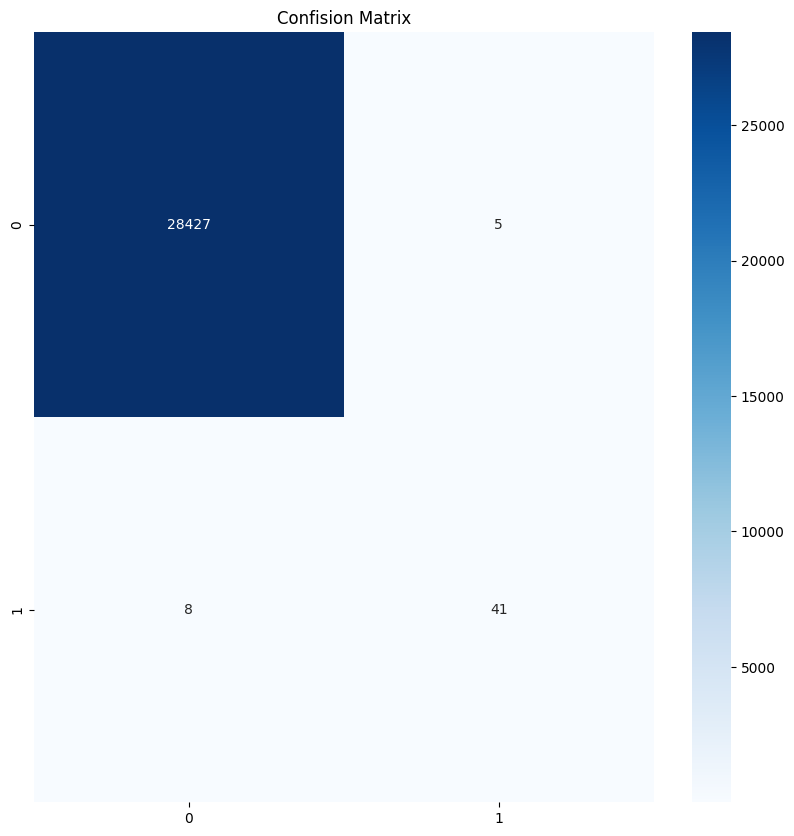

In [277]:
#Testing - Confision Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confision Matrix")
plt.show()

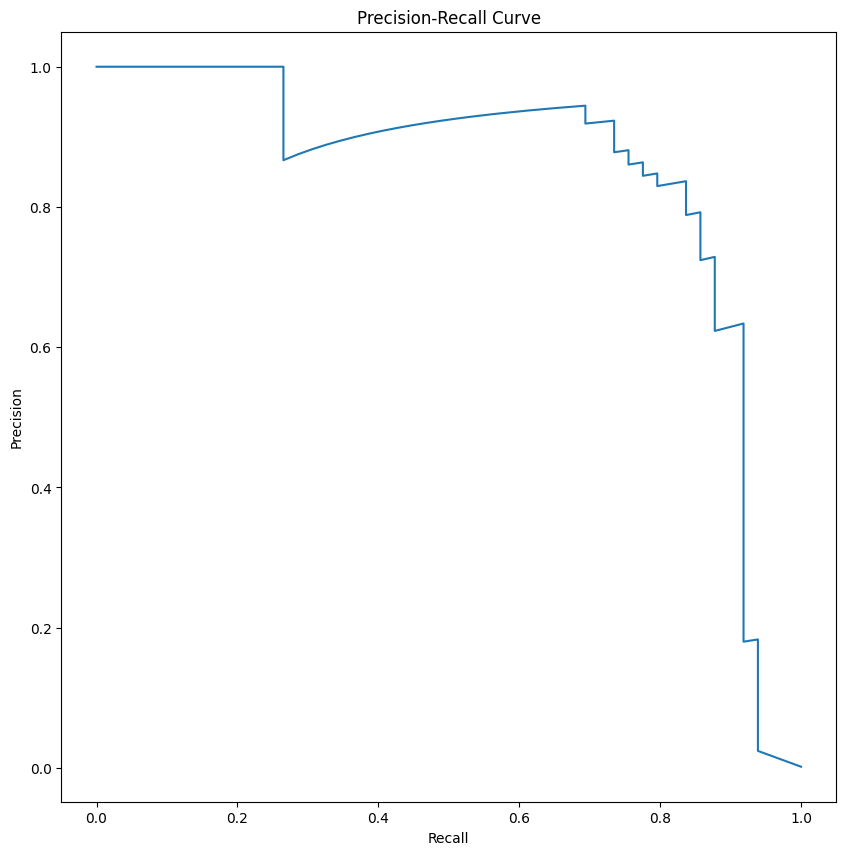

In [278]:
#Testing - Precision - Recall

y_prob = model.predict_proba(X_test_sel)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 10))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()